# ✅ Solutions — Module 8 — Experimental Design, Power & the Pitfalls of Testing

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
from statsmodels.stats.power import TTestIndPower, NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.multitest import multipletests

### ✍️ Exercise 8.1 — *Simpson's paradox*: Was there gender bias in Berkeley's graduate admissions? (Real data, 1973)

In 1973 the University of California, Berkeley, feared a lawsuit: men were admitted to graduate school at a visibly higher rate than women. The data below covers the six largest departments (Bickel, Hammel & O'Connell, *Science* 1975).

**Tasks**
1. Compute the overall admission rate by gender.
2. Compute the admission rate by gender **within each department** and plot it.
3. Explain the contradiction: to which departments did women and men mainly apply, and how selective are those departments?
4. What is the right conclusion?

In [2]:
ucb = pd.DataFrame({"dept": list("ABCDEF") * 2, "gender": ["men"] * 6 + ["women"] * 6,
                    "admitted":   [512, 353, 120, 138, 53, 22,   89, 17, 202, 131, 94, 24],
                    "applicants": [825, 560, 325, 417, 191, 373, 108, 25, 593, 375, 393, 341]})
ucb

,dept,gender,admitted,applicants
0,A,men,512,825
1,B,men,353,560
2,C,men,120,325
3,D,men,138,417
4,E,men,53,191
5,F,men,22,373
6,A,women,89,108
7,B,women,17,25
8,C,women,202,593
9,D,women,131,375


        admitted  applicants   rate
gender                             
men         1198        2691  0.445
women        557        1835  0.304 

gender   men  women  dept admission rate  share of all women applying here  \
dept                                                                         
A       0.62   0.82                 0.64                              0.06   
B       0.63   0.68                 0.63                              0.01   
C       0.37   0.34                 0.35                              0.32   
D       0.33   0.35                 0.34                              0.20   
E       0.28   0.24                 0.25                              0.21   
F       0.06   0.07                 0.06                              0.19   

gender  share of all men applying here  
dept                                    
A                                 0.31  
B                                 0.21  
C                                 0.12  
D                       

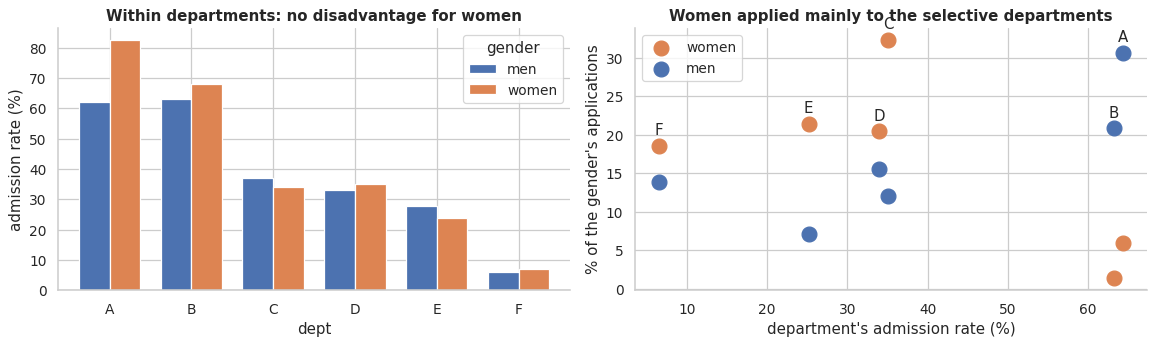

In [3]:
overall = ucb.groupby("gender")[["admitted", "applicants"]].sum(); overall["rate"] = overall.admitted / overall.applicants
print(overall.round(3), "\n")
ucb["rate"] = ucb.admitted / ucb.applicants
by_dept = ucb.pivot(index="dept", columns="gender", values="rate")
by_dept["dept admission rate"] = ucb.groupby("dept").admitted.sum() / ucb.groupby("dept").applicants.sum()
share = ucb.pivot(index="dept", columns="gender", values="applicants"); share = share / share.sum()
by_dept["share of all women applying here"], by_dept["share of all men applying here"] = share.women, share.men
print(by_dept.round(2))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
by_dept[["men", "women"]].mul(100).plot.bar(ax=a1, color=[C[0], C[1]], rot=0, width=.75); a1.set(ylabel="admission rate (%)", title="Within departments: no disadvantage for women")
a2.scatter(by_dept["dept admission rate"] * 100, share.women * 100, s=140, color=C[1], label="women"); a2.scatter(by_dept["dept admission rate"] * 100, share.men * 100, s=140, color=C[0], label="men")
for dpt, r in by_dept.iterrows(): a2.annotate(dpt, (r["dept admission rate"] * 100, max(share.women[dpt], share.men[dpt]) * 100), xytext=(0, 9), textcoords="offset points", ha="center")
a2.set(xlabel="department's admission rate (%)", ylabel="% of the gender's applications", title="Women applied mainly to the selective departments"); a2.legend(); plt.tight_layout(); plt.show()

**Interpretation.** Overall, about 45 % of male but only 30 % of female applicants were admitted — a gap of 14 points. Yet **within departments** the gap disappears: in four of six departments women had the *higher* admission rate (strikingly so in department A: 82 % vs. 62 %).

The resolution is the **choice of department** (the confounder): more than half of the men applied to departments A and B, which admit over 60 % of applicants, whereas the large majority of women applied to departments C–F, which admit between 6 % and 35 %. Pooling mixes "which department?" with "which gender?".

**Conclusion:** the aggregate data give no evidence of bias in the *admission decisions* of the departments. (Why women applied to the more competitive fields — and why those fields had fewer places — is a separate, legitimate question that these data cannot answer.) **Lesson:** always ask which variable determines the *group sizes* before trusting an aggregate comparison.

### ✍️ Exercise 8.2 — *Power analysis*: How long must the A/B test run? (Product experimentation)

Your shop converts **4.0 %** of visitors. The product team believes a new checkout could lift this to **4.4 %** and says smaller improvements are not worth the engineering effort. You get **6,000 visitors per day**, split 50/50.

**Tasks**
1. Required visitors per arm for $\alpha = 0.05$ (two-sided) and 80 % power — with `NormalIndPower` and with the formula $n = (z_{1-\alpha/2}+z_{1-\beta})^2\,[p_1(1-p_1)+p_2(1-p_2)]/\delta^2$.
2. How many days must the test run? (Round up to full weeks — why?)
3. The team is impatient and wants to stop after 7 days. What power would the test have?
4. What if the MDE were +0.2 percentage points instead? Plot power against run time for both MDEs.

In [4]:
p0, p1, daily_visitors = .040, .044, 6000

n per arm: statsmodels 39,454, formula 39,472  ->  13.2 days  ->  run 14 days (full weeks)
power after 7 days (n = 21,000 per arm): 53%
MDE +0.2 pp: n per arm = 154,282  ->  51 days


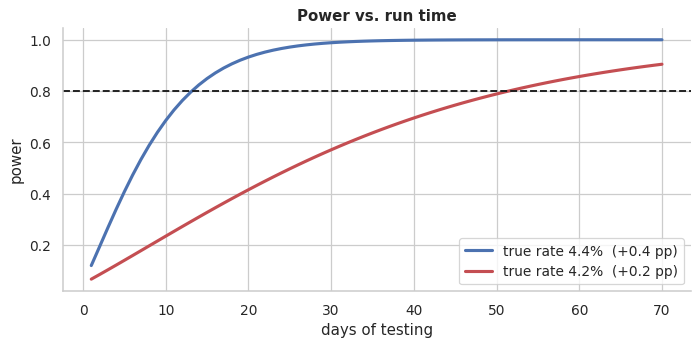

In [5]:
pz = NormalIndPower()
h = proportion_effectsize(p1, p0)
n_sm = pz.solve_power(effect_size=h, alpha=.05, power=.8)
n_formula = (stats.norm.ppf(.975) + stats.norm.ppf(.8)) ** 2 * (p0 * (1 - p0) + p1 * (1 - p1)) / (p1 - p0) ** 2
days = 2 * n_sm / daily_visitors
print(f"n per arm: statsmodels {n_sm:,.0f}, formula {n_formula:,.0f}  ->  {days:.1f} days  ->  run {int(np.ceil(days / 7) * 7)} days (full weeks)")
print(f"power after 7 days (n = {7 * daily_visitors // 2:,} per arm): {pz.power(h, nobs1=7 * daily_visitors / 2, alpha=.05):.0%}")
n_small = pz.solve_power(proportion_effectsize(.042, p0), alpha=.05, power=.8)
print(f"MDE +0.2 pp: n per arm = {n_small:,.0f}  ->  {2 * n_small / daily_visitors:.0f} days")

d = np.arange(1, 71)
fig, ax = plt.subplots(figsize=(9, 3.8))
for p_alt, col in [(.044, C[0]), (.042, C[3])]:
    ax.plot(d, pz.power(proportion_effectsize(p_alt, p0), nobs1=d * daily_visitors / 2, alpha=.05), color=col, lw=2.5, label=f"true rate {p_alt:.1%}  (+{(p_alt - p0) * 100:.1f} pp)")
ax.axhline(.8, color="k", ls="--"); ax.set(xlabel="days of testing", ylabel="power", title="Power vs. run time"); ax.legend(); plt.show()

**Interpretation.** Detecting +0.4 pp on a 4 % base needs about **39,500 visitors per arm**, i.e. just over 13 days → run **14 days**. Full weeks matter because weekday and weekend visitors behave differently; a test covering 1.9 weeks over-weights some weekdays.

Stopping after 7 days gives only about **53 % power** — a coin flip whether a real +0.4 pp improvement is detected, and if it *is* significant the estimate will be inflated (winner's curse, section 4). Halving the MDE to +0.2 pp quadruples the requirement: ≈ 155,000 per arm, more than seven weeks.

**Lesson:** the MDE discussion is a *business* discussion ("what is the smallest lift worth shipping?") and must happen before the test. Small shops cannot detect small effects — they should test bold changes.

### ✍️ Exercise 8.3 — *Multiple testing*: 25 segments, 6 "significant" results — how many are real? (Marketing analytics)

After an e-mail campaign test, an analyst compares treatment vs. control separately in 25 customer segments and proudly reports every segment with $p<0.05$. (In this simulation we know the truth: the campaign works in exactly three segments.)

**Tasks**
1. How many segments are "significant" without correction? How many false positives would you *expect* among 22 true nulls?
2. Apply Bonferroni, Holm and Benjamini–Hochberg. Tabulate true and false positives for each method.
3. Which method suits (i) a confirmatory claim to the board, (ii) an exploratory screening for follow-up tests?

In [6]:
g = np.random.default_rng(833)
segments = [f"S{i:02d}" for i in range(1, 26)]
true_effect = np.zeros(25); true_effect[[3, 11, 19]] = .22                     # the campaign only works in S04, S12, S20
pvals = pd.Series([stats.ttest_ind(g.normal(e, 1, 400), g.normal(0, 1, 400)).pvalue for e in true_effect], index=segments)
pvals.sort_values().head(8).round(4)

S12    0.0000
S20    0.0004
S04    0.0038
S09    0.0214
S23    0.0239
S24    0.0828
S06    0.1279
S05    0.1458
dtype: float64

expected false positives without correction: 22 × 0.05 = 1.1



,flagged segments,true pos.,false pos.
none,"S04, S09, S12, S20, S23",3,2
bonferroni,"S12, S20",2,0
holm,"S12, S20",2,0
fdr_bh,"S04, S12, S20",3,0


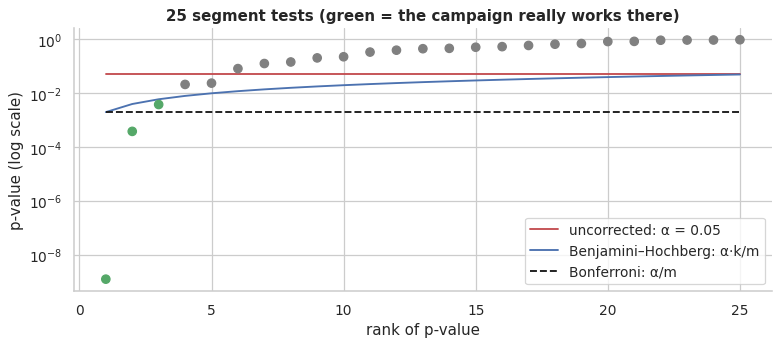

In [7]:
real = pd.Series(true_effect > 0, index=segments)
print(f"expected false positives without correction: 22 × 0.05 = {22 * .05:.1f}\n")
rows = {}
for method in ["none", "bonferroni", "holm", "fdr_bh"]:
    rej = pvals < .05 if method == "none" else pd.Series(multipletests(pvals, alpha=.05, method=method)[0], index=segments)
    rows[method] = {"flagged segments": ", ".join(pvals.index[rej]), "true pos.": int((rej & real).sum()), "false pos.": int((rej & ~real).sum())}
pd.set_option("display.max_colwidth", 80); display(pd.DataFrame(rows).T)
order = pvals.sort_values(); k = np.arange(1, 26)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.scatter(k, order.values, c=[C[2] if real[seg] else "grey" for seg in order.index], s=45, zorder=3)
ax.plot(k, np.full(25, .05), color=C[3], label="uncorrected: α = 0.05"); ax.plot(k, .05 * k / 25, color=C[0], label="Benjamini–Hochberg: α·k/m"); ax.plot(k, np.full(25, .05 / 25), "k--", label="Bonferroni: α/m")
ax.set(yscale="log", xlabel="rank of p-value", ylabel="p-value (log scale)", title="25 segment tests (green = the campaign really works there)"); ax.legend(); plt.show()

**Interpretation.** Without correction the analyst reports five segments: the three real ones **plus two false alarms** — in line with theory (about one false positive expected among 22 true nulls, give or take). Bonferroni and Holm remove both false alarms but also **lose one of the three real effects**, whose p-value is small but not below $0.05/25 = 0.002$. Benjamini–Hochberg keeps all three real segments and none of the false ones.

**Which method when?** (i) For a confirmatory claim ("the campaign works in segment X") control the **FWER** → Holm. (ii) For screening ("which segments deserve a follow-up test?") control the **FDR** → Benjamini–Hochberg; a few false leads are acceptable because the follow-up test weeds them out.

**Lesson:** the number of tests you *ran* — not the number you *report* — determines the correction.

### ✍️ Exercise 8.4 — *Peeking*: What does "we stop when it's significant" really cost? (Experimentation platform)

A team checks its A/B tests every morning for 14 days and stops as soon as $p<0.05$. You are given the z-statistics of 20,000 simulated **A/A tests** (no true effect) after each day.

**Tasks**
1. What is the false-positive rate if only the final analysis on day 14 counts?
2. What is it under the team's stop-at-first-significance policy?
3. On which days do the false alarms occur? Plot the distribution of the stopping day.
4. Find, by trial over a grid, the constant per-look significance level $\alpha^*$ (a *Pocock-type* boundary) that brings the overall false-positive rate back to 5 %.

In [8]:
g = np.random.default_rng(804)
R, looks, n_day = 20_000, 14, 500
cum_a = g.normal(0, np.sqrt(n_day), (R, looks)).cumsum(axis=1); cum_b = g.normal(0, np.sqrt(n_day), (R, looks)).cumsum(axis=1)
z = (cum_a - cum_b) / np.sqrt(2 * n_day * np.arange(1, looks + 1))            # z[i, d] = z-statistic of experiment i after day d+1
pvals = 2 * stats.norm.sf(np.abs(z)); pvals.shape

(20000, 14)

final look only        : FPR = 0.050
stop at first p < 0.05 : FPR = 0.223
per-look alpha that restores 5 % overall: alpha* ≈ 0.0090  (|z| > 2.61 instead of 1.96)


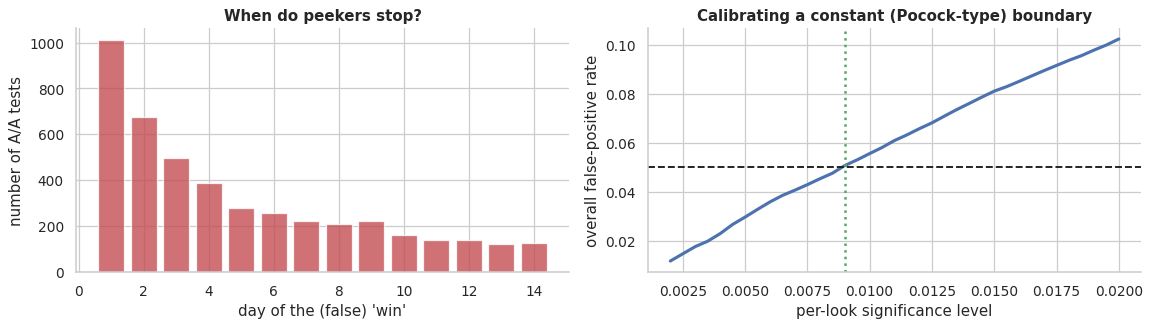

In [9]:
print(f"final look only        : FPR = {(pvals[:, -1] < .05).mean():.3f}")
hit = pvals < .05
print(f"stop at first p < 0.05 : FPR = {hit.any(axis=1).mean():.3f}")
stop_day = hit.argmax(axis=1)[hit.any(axis=1)] + 1

grid = np.linspace(.002, .02, 37)
fpr = np.array([(pvals < a).any(axis=1).mean() for a in grid])
a_star = grid[np.abs(fpr - .05).argmin()]
print(f"per-look alpha that restores 5 % overall: alpha* ≈ {a_star:.4f}  (|z| > {stats.norm.isf(a_star / 2):.2f} instead of 1.96)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.8))
a1.bar(*np.unique(stop_day, return_counts=True), color=C[3], alpha=.8); a1.set(xlabel="day of the (false) 'win'", ylabel="number of A/A tests", title="When do peekers stop?")
a2.plot(grid, fpr, color=C[0], lw=2.5); a2.axhline(.05, color="k", ls="--"); a2.axvline(a_star, color=C[2], ls=":", lw=2)
a2.set(xlabel="per-look significance level", ylabel="overall false-positive rate", title="Calibrating a constant (Pocock-type) boundary"); plt.tight_layout(); plt.show()

**Interpretation.** Looking once: 5 %, as promised. Looking daily for two weeks and stopping at the first significant result: about **22 %** — more than four times the nominal rate. Many false wins happen in the first days, when little data has accumulated and the z-statistic fluctuates most; these are precisely the "amazing early results" that excite teams.

To keep 5 % overall with 14 looks, each look must use $\alpha^* \approx 0.008$–$0.009$ ($|z| > 2.6$). That price — a stricter threshold at the final analysis too — is why professional designs use few interim looks, or O'Brien–Fleming-type boundaries that spend almost no $\alpha$ early.

**Lesson:** optional stopping is not a harmless habit. Either fix the horizon, or use a sequential design that was built for peeking.

### ✍️ Exercise 8.5 — *CUPED*: Sharpening an experiment with pre-period data (Online retail)

An experiment tested a new recommendation widget (2,000 users per arm). Outcome: spend during the 4-week test. For every user you also know the spend in the 4 weeks **before** the test.

**Tasks**
1. Estimate the treatment effect with a plain Welch $t$-test (estimate, 95 % CI, p-value).
2. Compute $\theta$ and the CUPED-adjusted outcome; repeat the analysis.
3. By how much did the CI shrink? Compare with the theoretical factor $\sqrt{1-\rho^2}$. How many users would the plain analysis need for the same precision?
4. Why must the covariate come from *before* the experiment?

In [10]:
g = np.random.default_rng(805)
n = 2000
pre = g.gamma(2, 30, 2 * n)
group = g.permutation(np.r_[np.zeros(n), np.ones(n)]).astype(int)
spend = (12 + .85 * pre + g.normal(0, 22, 2 * n) + 2.5 * group).round(2)      # true effect: +2.50 €
exp = pd.DataFrame({"group": np.where(group == 1, "treatment", "control"), "pre_spend": pre.round(2), "spend": spend})
exp.groupby("group")[["pre_spend", "spend"]].mean().round(2)

,pre_spend,spend
group,,
control,58.65,61.82
treatment,58.77,64.60


,estimate,CI low,CI high,p-value,CI width
plain,2.7811,0.1592,5.4030,0.0376,5.2438
CUPED,2.6813,1.3204,4.0422,0.0001,2.7218


theta = 0.855, rho = 0.854;  CI width ratio = 0.519  vs. theory sqrt(1 − rho²) = 0.520
equivalent sample-size multiplier: 1 / (1 − rho²) = 3.7×


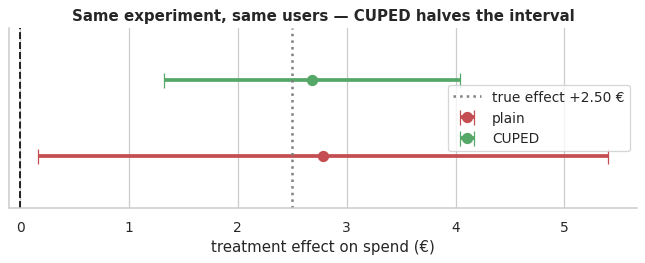

In [11]:
def analyse(col):
    t, c = exp.loc[exp.group == "treatment", col], exp.loc[exp.group == "control", col]
    r = stats.ttest_ind(t, c, equal_var=False); ci = r.confidence_interval()
    return t.mean() - c.mean(), ci.low, ci.high, r.pvalue

theta = np.cov(exp.pre_spend, exp.spend)[0, 1] / exp.pre_spend.var()
exp["spend_cuped"] = exp.spend - theta * (exp.pre_spend - exp.pre_spend.mean())
rho = exp[["pre_spend", "spend"]].corr().iloc[0, 1]
res = pd.DataFrame([analyse("spend"), analyse("spend_cuped")], index=["plain", "CUPED"], columns=["estimate", "CI low", "CI high", "p-value"])
res["CI width"] = res["CI high"] - res["CI low"]; display(res.round(4))
print(f"theta = {theta:.3f}, rho = {rho:.3f};  CI width ratio = {res['CI width'].iloc[1] / res['CI width'].iloc[0]:.3f}  vs. theory sqrt(1 − rho²) = {np.sqrt(1 - rho ** 2):.3f}")
print(f"equivalent sample-size multiplier: 1 / (1 − rho²) = {1 / (1 - rho ** 2):.1f}×")
fig, ax = plt.subplots(figsize=(9, 2.6))
for i, (name, r) in enumerate(res.iterrows()):
    ax.errorbar([r["estimate"]], [i], xerr=[[r["estimate"] - r["CI low"]], [r["CI high"] - r["estimate"]]], fmt="o", color=[C[3], C[2]][i], capsize=6, lw=3, ms=8, label=name)
ax.axvline(0, color="k", ls="--"); ax.axvline(2.5, color="grey", ls=":", lw=2, label="true effect +2.50 €"); ax.set(yticks=[], ylim=(-.7, 1.7), xlabel="treatment effect on spend (€)", title="Same experiment, same users — CUPED halves the interval"); ax.legend(); plt.show()

**Interpretation.** Both analyses estimate the same quantity and both are unbiased, but the plain estimate is so noisy that its CI is more than €5 wide and only just excludes zero. CUPED removes the part of each user's spend that was predictable from their past behaviour (big spenders stay big spenders); with $\rho \approx 0.85$ the CI shrinks to roughly **half** its width and the +€2.50 effect becomes clearly visible. To get the same precision without CUPED you would need about **3–4 times** as many users.

**Why pre-experiment data only?** If the covariate could itself be influenced by the treatment (e.g. number of sessions *during* the test), adjusting for it would remove part of the treatment effect and bias the estimate. Pre-period data cannot be affected by a treatment that had not started yet — and because assignment is random, $X$ is balanced between arms, which is what keeps the adjusted estimate unbiased.

### ✍️ Exercise 8.6 — *Regression to the mean*: Do speed cameras work? (Road-safety policy)

A region records accidents at 2,000 road sites. After year 1 it installs cameras at the **100 sites with the most accidents**. In year 2 accidents at those sites fall dramatically, and the press release writes itself. In this simulation the cameras have **no effect at all** — each site's underlying accident rate is identical in both years.

**Tasks**
1. Compute the mean accident count of the 100 camera sites in year 1 and in year 2, and the apparent reduction in %.
2. What happened at the other 1,900 sites?
3. Explain the result. How large is the correlation between year 1 and year 2?
4. Propose an evaluation design that would give an honest answer.

In [12]:
g = np.random.default_rng(806)
true_rate = g.gamma(4, 1.5, 2000)                                  # each site's long-run accident rate (mean 6 per year)
sites = pd.DataFrame({"year1": g.poisson(true_rate), "year2": g.poisson(true_rate)})
sites["camera"] = sites.year1.rank(method="first", ascending=False) <= 100
sites.describe().round(2)

,year1,year2
count,2000.00,2000.00
mean,6.09,6.04
std,3.93,3.90
min,0.00,0.00
25%,3.00,3.00
50%,5.00,5.00
75%,8.00,8.00
max,24.00,27.00


         year1   year2  change
camera                        
False    5.553   5.762   0.038
True    16.230  11.360  -0.300

correlation year 1 vs year 2: r = 0.59


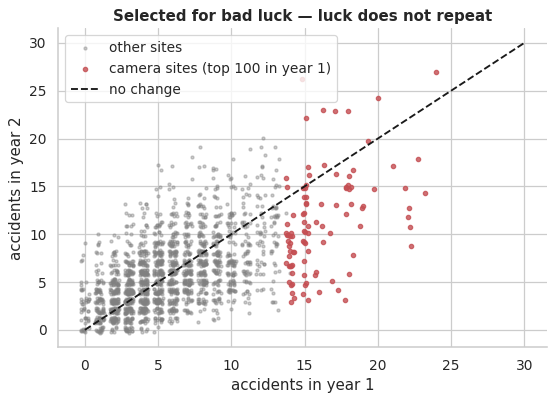

In [13]:
summary = sites.groupby("camera")[["year1", "year2"]].mean()
summary["change"] = summary.year2 / summary.year1 - 1
print(summary.round(3)); print(f"\ncorrelation year 1 vs year 2: r = {sites.year1.corr(sites.year2):.2f}")

fig, ax = plt.subplots(figsize=(7, 4.6))
jit = lambda s: s + g.uniform(-.3, .3, s.size)
ax.scatter(jit(sites.year1[~sites.camera]), jit(sites.year2[~sites.camera]), s=6, color="grey", alpha=.4, label="other sites")
ax.scatter(jit(sites.year1[sites.camera]), jit(sites.year2[sites.camera]), s=12, color=C[3], alpha=.8, label="camera sites (top 100 in year 1)")
ax.plot([0, 30], [0, 30], "k--", label="no change"); ax.set(xlabel="accidents in year 1", ylabel="accidents in year 2", title="Selected for bad luck — luck does not repeat"); ax.legend(); plt.show()

**Interpretation.** Accidents at the camera sites drop by **30 %** (from about 16 to 11 per site) — without any camera effect. The sites were selected *because* they had an extreme year: a high count is partly a genuinely dangerous site and partly bad luck, and only the first part persists. The year-to-year correlation of only ≈ 0.6 shows how much of a single year's count is noise. Meanwhile the other 1,900 sites get slightly *worse* (+4 %) — the mirror image of the same effect.

**Honest designs:** (1) **randomise** cameras among the 200 worst sites and compare treated vs. untreated *selected* sites — both regress equally, the difference is the camera effect; (2) if randomisation is impossible, select on a multi-year average and use an *empirical-Bayes* before–after analysis that predicts the expected regression; (3) never compare extreme units with their own past without a control.

**Lesson:** "we intervened where things were worst, and they improved" is the single most common statistical illusion in business, medicine and policy.